# Data Overview

### Import Libraries

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [28]:
hurricanes = pd.read_csv("data/cleaned_data.csv") # renamed kaggle csv from storms to hurricane_data

### Inspect Dataset

In [29]:
print(hurricanes.head())
print(hurricanes.info())
print(hurricanes.columns)

                  name  year  month  day  hour   lat  long     status  \
0              Blanche  1975      7   27    60  35.9 -70.0  hurricane   
1              Blanche  1975      7   27    12  36.9 -69.0  hurricane   
2              Blanche  1975      7   27    18  37.9 -68.0  hurricane   
3              Blanche  1975      7   28     0  39.3 -67.2  hurricane   
4              Blanche  1975      7   28    60  41.2 -66.4  hurricane   

   category  wind  pressure  tropicalstorm_force_diameter  \
0       1.0    65       987                           212   
1       1.0    70       984                           220   
2       1.0    75       981                           230   
3       1.0    75       980                           730   
4       1.0    70       980                           492   

   hurricane_force_diameter  hurricane_class  
0                        59                0  
1                        63                0  
2                        64                0  
3     

NOTES: The dataset contains 5,100 hurricane observations and 14 variables. Variables include temporal information (year, month, day, hour), geographic location (latitude and longitude), storm intensity measures (wind, pressure), storm size measures, and hurricane category.

# EDA: Hurricane observations

### Summary Statistics

In [30]:
print("=== Hurricane Category Counts ===")
category_counts = hurricanes['category'].value_counts().sort_index()
print(category_counts)
print("\n=== Hurricane Category Percentages ===")
category_percentages = (
    hurricanes['category'].value_counts(normalize=True)
    .sort_index() * 100
)

print(category_percentages.round(2))
print("=== Numerical Variable Summary ===")
display(hurricanes.describe())

=== Hurricane Category Counts ===
category
1.0    2707
2.0    1046
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64

=== Hurricane Category Percentages ===
category
1.0    53.08
2.0    20.51
3.0    12.39
4.0    11.49
5.0     2.53
Name: proportion, dtype: float64
=== Numerical Variable Summary ===


,year,month,day,hour,lat,long,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter,hurricane_class
count,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.00000,5100.000000,5100.000000,5100.000000,5100.000000
mean,2002.482353,8.955490,15.805098,22.860784,26.428667,-63.904118,1.898824,86.67549,968.609020,256.289608,65.301176,0.264118
std,13.633805,0.963839,8.987628,22.696014,8.101691,16.719401,1.154117,20.71107,18.711738,105.954981,33.402075,0.440905
min,1975.000000,1.000000,1.000000,0.000000,9.500000,-119.300000,1.000000,65.00000,882.000000,50.000000,10.000000,0.000000
25%,1993.000000,8.000000,8.000000,12.000000,19.800000,-76.200000,1.000000,70.00000,957.000000,200.000000,45.000000,0.000000
50%,2003.000000,9.000000,16.000000,18.000000,26.300000,-63.200000,1.000000,80.00000,973.000000,230.000000,60.000000,0.000000
75%,2015.000000,9.000000,24.000000,30.000000,32.400000,-51.675000,3.000000,100.00000,983.000000,295.000000,75.000000,1.000000
max,2024.000000,12.000000,31.000000,94.000000,50.800000,-14.100000,5.000000,165.00000,1005.000000,870.000000,300.000000,1.000000


NOTES:
Hurricane Categories
Category 1 hurricanes represent over half of all observations (53.08%), while Category 5 hurricanes account for only 2.53%. This indicates an imbalance toward weaker hurricanes.

Numerical Variables
The maximum value of 94 for hour appears unusual since valid observation hours are typically 0, 6, 12, or 18 UTC. This may represent a data quality issue or special coding convention and should be investigated before modeling.

### Distribution Analysis
#### Wind Speed and Pressure Histogram

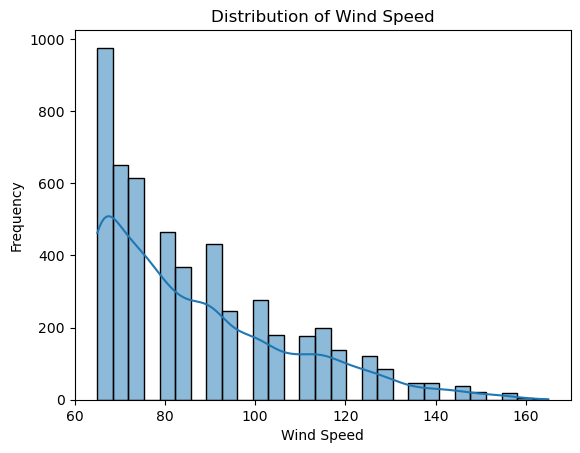

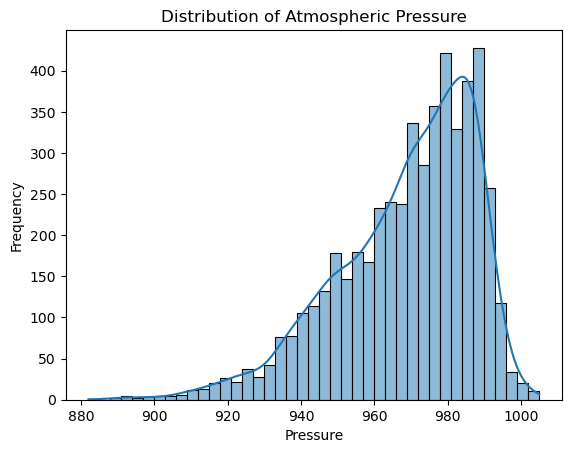

In [31]:
sns.histplot(hurricanes['wind'], kde=True)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")

plt.show()
sns.histplot(hurricanes['pressure'], kde=True)

plt.title("Distribution of Atmospheric Pressure")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.show()

NOTES:
Wind Histogram
Wind speed is right-skewed, with most observations concentrated between 65 and 100 mph. Higher wind speeds occur less frequently and represent stronger hurricanes.

Pressure Histogram
Atmospheric pressure is left-skewed. Most observations occur between 950 and 995 mb, while very low pressures are relatively rare and correspond to stronger hurricanes.

#### Category Distribution

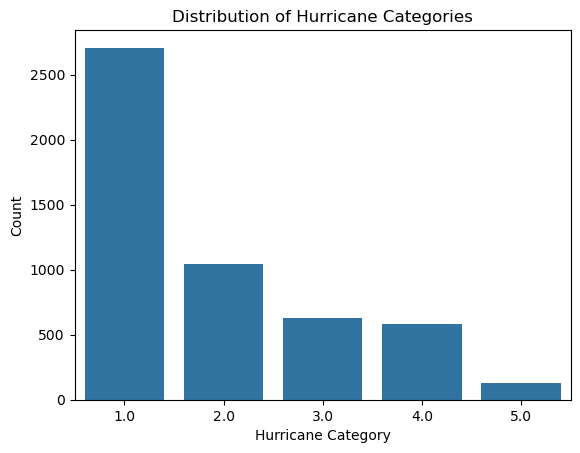

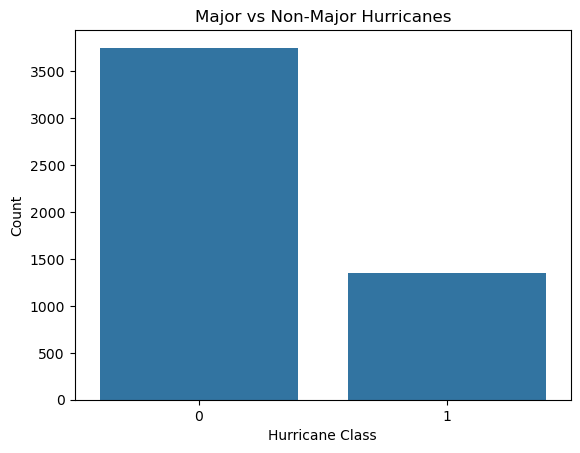

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=hurricanes)

plt.title("Distribution of Hurricane Categories")
plt.xlabel("Hurricane Category")
plt.ylabel("Count")

plt.show()
sns.countplot(
    x='hurricane_class',
    data=hurricanes
)

plt.title("Major vs Non-Major Hurricanes")
plt.xlabel("Hurricane Class")
plt.ylabel("Count")
plt.show()

NOTES: The distribution is imbalanced, with Category 1 storms dominating the dataset. Category 5 storms are relatively rare, which may affect predictive model performance.

### Correlation Analysis

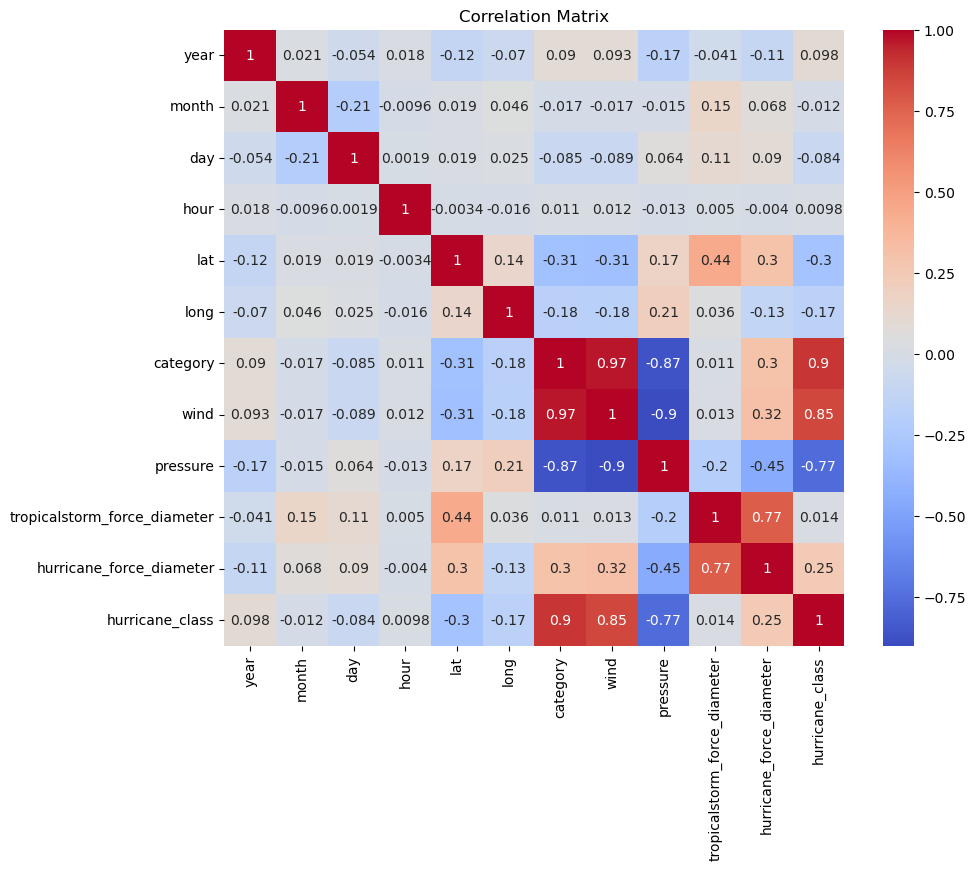

,Variable,Correlation with Hurricane Class
0,wind,0.846677
1,pressure,-0.766090
2,lat,-0.296294
3,hurricane_force_diameter,0.246509
4,long,-0.165833
5,year,0.098243
6,day,-0.084009
7,tropicalstorm_force_diameter,0.013946
8,month,-0.011558
9,hour,0.009790


In [33]:
numeric_cols = hurricanes.select_dtypes(include='number')
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
corr_summary = (
    correlation_matrix['hurricane_class']
    .drop(['hurricane_class', 'category'])
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

corr_table = pd.DataFrame({
    'Variable': corr_summary.index,
    'Correlation with Hurricane Class': corr_summary.values
})

display(corr_table)

NOTES: Wind speed (r = 0.85) and pressure (r = -0.77) are the strongest predictors of major hurricane classification. Latitude shows a moderate negative relationship (r = -0.30), while temporal variables contribute little predictive information.

#### Wind Analysis

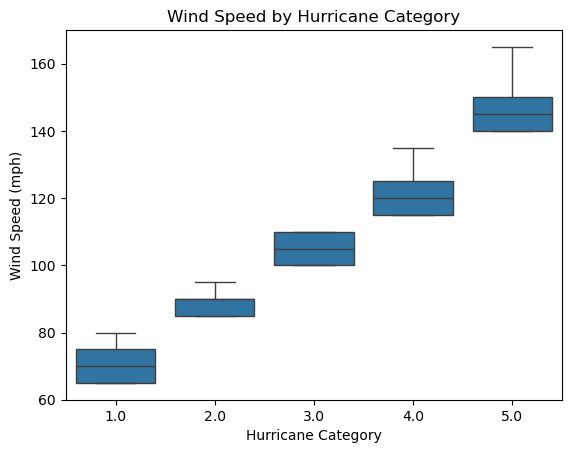

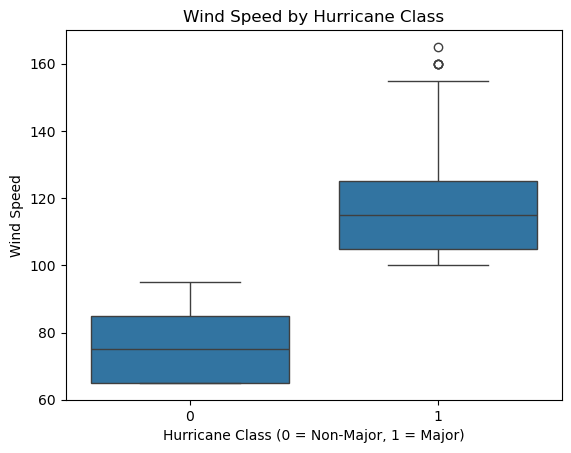

In [34]:
sns.boxplot(
    x='category',
    y='wind',
    data=hurricanes
)

plt.title("Wind Speed by Hurricane Category")
plt.xlabel("Hurricane Category")
plt.ylabel("Wind Speed (mph)")
plt.show()
sns.boxplot(
    x='hurricane_class',
    y='wind',
    data=hurricanes
)

plt.title("Wind Speed by Hurricane Class")
plt.xlabel("Hurricane Class (0 = Non-Major, 1 = Major)")
plt.ylabel("Wind Speed")
plt.show()

NOTES:
Wind by Category
Median wind speed increases consistently across hurricane categories, confirming that wind speed is a defining characteristic of hurricane intensity.

Wind by Major Hurricane Class
Major hurricanes exhibit substantially higher wind speeds than non-major hurricanes, with minimal overlap between groups.

#### Wind Atmospheric Pressure

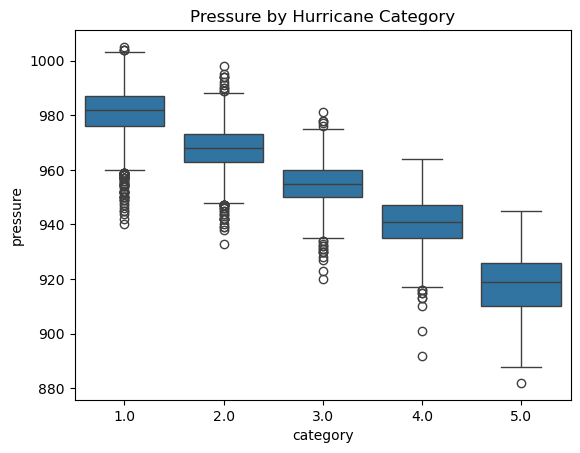

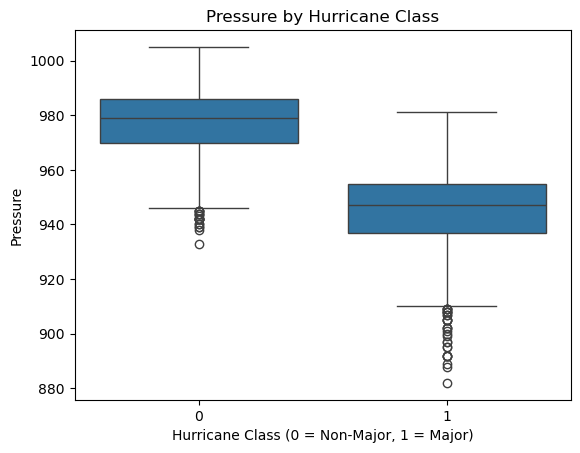

In [35]:
sns.boxplot(x='category', y='pressure', data=hurricanes)
plt.title("Pressure by Hurricane Category")
plt.show()
sns.boxplot(
    x='hurricane_class',
    y='pressure',
    data=hurricanes
)

plt.title("Pressure by Hurricane Class")
plt.xlabel("Hurricane Class (0 = Non-Major, 1 = Major)")
plt.ylabel("Pressure")
plt.show()

NOTES: 
Pressure by Category
Median atmospheric pressure decreases steadily as hurricane category increases.

Pressure by Hurricane Class
Major hurricanes exhibit significantly lower pressure values than non-major hurricanes, supporting pressure as an important predictor.

#### Wind vs Pressure Relationship

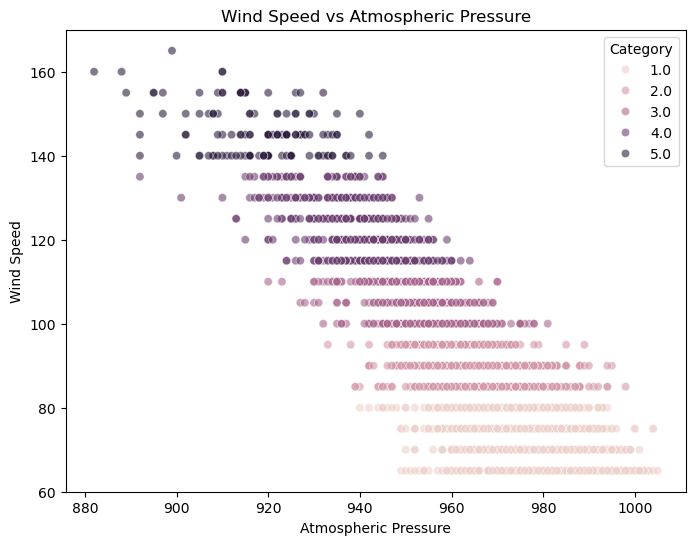

<Axes: title={'center': 'Pressure vs Wind Speed by Hurricane Class'}, xlabel='pressure', ylabel='wind'>

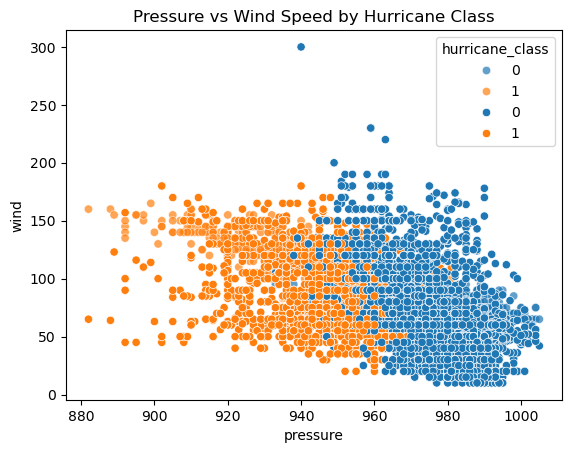

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='pressure',
    y='wind',
    hue='category',
    data=hurricanes,
    alpha=0.6
)

plt.title("Wind Speed vs Atmospheric Pressure")
plt.xlabel("Atmospheric Pressure")
plt.ylabel("Wind Speed")
plt.legend(title="Category")
plt.show()
sns.scatterplot(
    x='pressure',
    y='wind',
    hue='hurricane_class',
    data=hurricanes,
    alpha=0.7
)

plt.title("Pressure vs Wind Speed by Hurricane Class")
sns.scatterplot(
    x='pressure',
    y='hurricane_force_diameter',
    hue='hurricane_class',
    data=hurricanes
)

NOTES: A strong inverse relationship exists between wind speed and atmospheric pressure. As pressure decreases, wind speed increases. The separation between major and non-major hurricanes is visually apparent.

#### Geographic Analysis

<Axes: xlabel='lat', ylabel='wind'>

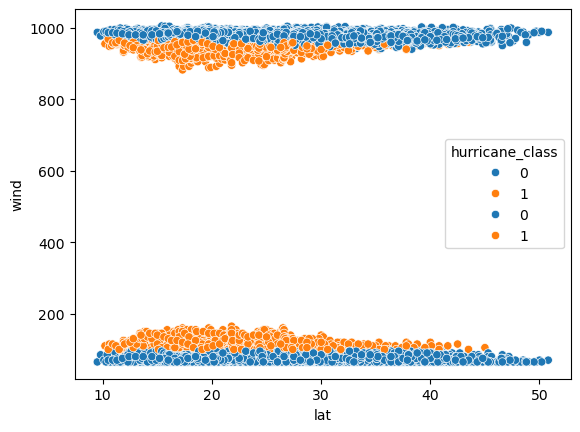

In [37]:
import plotly.express as px

fig = px.scatter_geo(
    hurricanes,
    lat='lat',
    lon='long',
    color='category',
    hover_name='name',
    projection='natural earth',
    title='Atlantic Hurricane Locations'
)

fig.show()
sns.scatterplot(
    x='lat',
    y='wind',
    hue='hurricane_class',
    data=hurricanes
)
sns.scatterplot(
    x='lat',
    y='pressure',
    hue='hurricane_class',
    data=hurricanes
)

NOTES: Stronger hurricanes tend to occur more frequently at lower latitudes, although considerable overlap exists. Latitude demonstrates only moderate predictive power compared to wind speed and pressure.

#### Seasonal Analysis

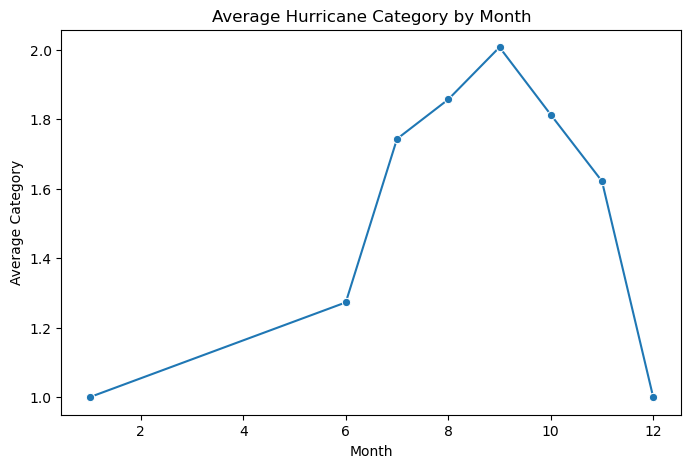

month
1      0.000000
6      9.090909
7     22.088353
8     24.771481
9     29.687500
10    23.946785
11    18.297872
12     0.000000
Name: hurricane_class, dtype: float64


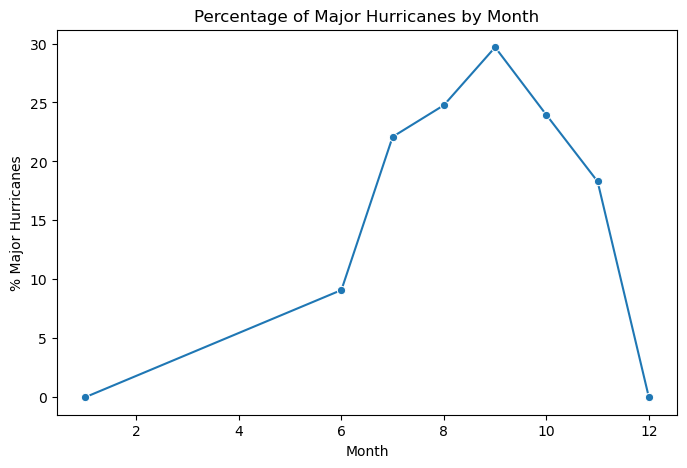

In [38]:
monthly_category = hurricanes.groupby('month')['category'].mean()

plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_category.index,
    y=monthly_category.values,
    marker='o'
)

plt.title("Average Hurricane Category by Month")
plt.xlabel("Month")
plt.ylabel("Average Category")

plt.show()
monthly_major = hurricanes.groupby('month')['hurricane_class'].mean() * 100

print(monthly_major)
plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_major.index,
    y=monthly_major.values,
    marker='o'
)

plt.title("Percentage of Major Hurricanes by Month")
plt.xlabel("Month")
plt.ylabel("% Major Hurricanes")

plt.show()

NOTES:
Average Category
Hurricane intensity peaks during September, consistent with the Atlantic hurricane season.

Major Hurricane Percentage
The percentage of major hurricanes reaches its highest level during September and declines afterward.

# Logistic Regression

The goal is to predict whether a hurricane becomes major or non major using the env conditions

we can easily interprey that with log regression so each coefficient tells us how a variale pushes a storm toward major/nonmajor

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report,ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.pipeline import Pipeline

## Target & Predictor Selection

Target variable: major = 1 if Category 3–5, else 0
Predictors used: `pressure`, `lat`, `long`


excluded wind since we can tell hurricances by the speed of the wind and we would have data leakage from that

In [ ]:
features = ["pressure", "lat", "long"]

#(1 = major, 0 = non-major)
modeldf = hurricanes[features + ["hurricane_class"]].dropna()
X = modeldf[features]
y = modeldf["hurricane_class"]

# stratify for ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 4080 | Testing samples: 1020


In [41]:
lrpipeline = Pipeline([
    ("scaler", StandardScaler()),# scale features
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lrpipeline.fit(X_train, y_train)
ypred_lr = lrpipeline.predict(X_test)
yprob_lr = lrpipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, ypred_lr, target_names=["Non-Major", "Major"]))
print(f"ROC-AUC: {roc_auc_score(y_test, yprob_lr):.4f}")

cv = cross_val_score(lrpipeline, X, y, cv=5, scoring="roc_auc")
print(f"Cross Validation ROC-AUC: {cv.mean():.4f} ± {cv.std():.4f}")

Logistic Regression
              precision    recall  f1-score   support

   Non-Major       0.95      0.97      0.96       751
       Major       0.92      0.85      0.88       269

    accuracy                           0.94      1020
   macro avg       0.93      0.91      0.92      1020
weighted avg       0.94      0.94      0.94      1020

ROC-AUC: 0.9809
Cross Validation ROC-AUC: 0.9769 ± 0.0104


In [42]:
# Elastic Net
en_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet", solver="saga",
        l1_ratio=0.5,    # 50% L1 (selection) + 50% L2 (stability)
        C=1.0,
        max_iter=1000, random_state=42
    ))
])
en_pipeline.fit(X_train, y_train)
y_pred_en = en_pipeline.predict(X_test)
y_prob_en = en_pipeline.predict_proba(X_test)[:, 1]
print("Elastic Net")
print(classification_report(y_test, y_pred_en, target_names=["Non-Major", "Major"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_en):.4f}")

Elastic Net
              precision    recall  f1-score   support

   Non-Major       0.95      0.97      0.96       751
       Major       0.92      0.85      0.88       269

    accuracy                           0.94      1020
   macro avg       0.93      0.91      0.92      1020
weighted avg       0.94      0.94      0.94      1020

ROC-AUC: 0.9809


          Logistic Regression  Elastic Net
Feature                                   
pressure              -4.1124      -4.1470
lat                   -1.0888      -1.0932
long                   0.1053       0.1051


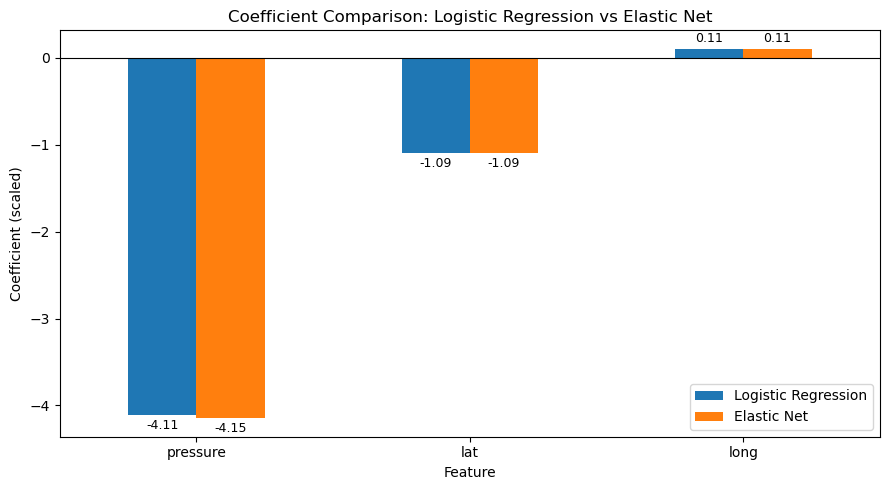

In [43]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Logistic Regression": lrpipeline.named_steps["model"].coef_[0],
    "Elastic Net": en_pipeline.named_steps["model"].coef_[0]
}).set_index("Feature")

print(coef_df.round(4))

ax = coef_df.plot(kind="bar", figsize=(9, 5))
plt.title("Coefficient Comparison: Logistic Regression vs Elastic Net")
plt.ylabel("Coefficient (scaled)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [44]:
import statsmodels.api as sm
Xtrainscaled = StandardScaler().fit_transform(X_train)
Xtrainsm = sm.add_constant(Xtrainscaled)

logit_model = sm.Logit(y_train.values, Xtrainsm).fit()
print(logit_model.summary(xname=["const"] + features))

Optimization terminated successfully.
         Current function value: 0.173342
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4080
Model:                          Logit   Df Residuals:                     4076
Method:                           MLE   Df Model:                            3
Date:                Tue, 23 Jun 2026   Pseudo R-squ.:                  0.6998
Time:                        10:38:48   Log-Likelihood:                -707.24
converged:                       True   LL-Null:                       -2355.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6226      0.106    -24.858      0.000      -2.829      -2.416
pressure      -4.2185      0.

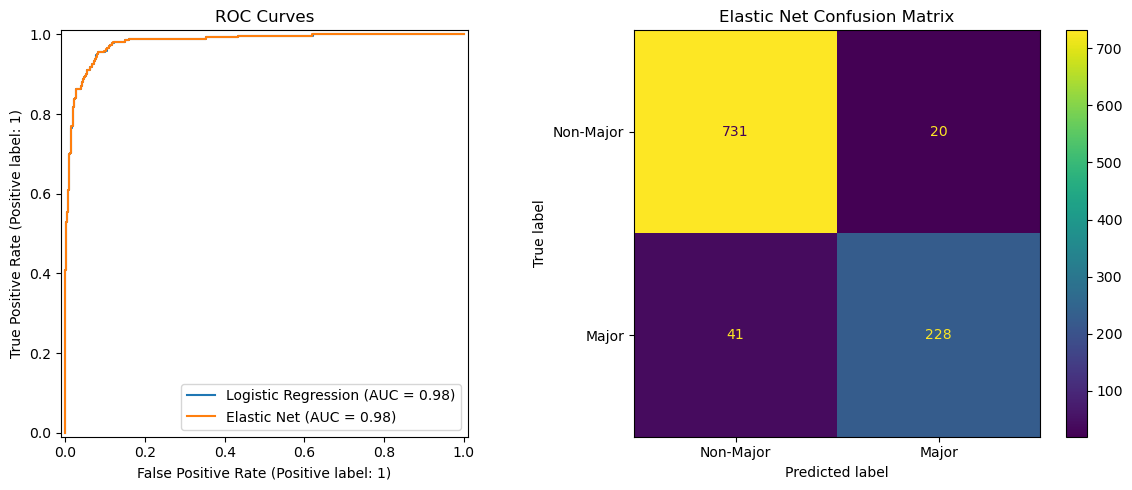

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, yprob_lr, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_prob_en, name="Elastic Net", ax=axes[0])
axes[0].set_title("ROC Curves")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_en, display_labels=["Non-Major", "Major"], ax=axes[1]
)
axes[1].set_title("Elastic Net Confusion Matrix")

plt.tight_layout()
plt.show()

###  FIndings

Model Performance: 
Both had identical results, ROC-AUC was 0.98 both of them distinguish major from non major with high accuracy, they overlap on the ROC plot showing us that EN did not show any improvement over the baseline, which is expected with 3 predictors. 

Confusion Matrix: (1020 test sample):
723 non major correcly classified
230 major correctly classified
28 non major incorrectly predicted as major
39 major incorrectly predicted as non major

it is strong with predicted non major (96% precision) and major (89% precision). The 39 missed major ones are the consequtial errors. 

Most important predictors were 
pressure:
coef −4.23, p < 0.001, strongest predictor by far.
Lower atmospheric pressure strongly signals a major hurricane.

lat:
coef −1.13, p < 0.001, significant. Storms closer to the
tropics are more likely to intensify.

long:
coef +0.09, p = 0.207, not statistically significant.
East/west position does not predict hurricane intensity.